## Attempt 1 on Emotion Detection based on recurrent audio encoding

In [121]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from tqdm import tqdm
from IPython.display import Audio, display


# Configuration
DATA_DIR = "/kaggle/input/"
CSV_PATH = os.path.join(DATA_DIR, "/kaggle/working/iemocap_regression_metadata.csv")
DATASET = os.path.join(DATA_DIR, "iemocapfullrelease/IEMOCAP_full_release")
MFCC_PATH = os.path.join(DATA_DIR, "mfcc-regression")
MODEL_SAVE_PATH = "/kaggle/working/emotion_classifier.pt"

BATCH_SIZE = 16
NUM_EPOCHS = 30
MAX_LEN = 128
N_MFCC = 13
SR = 16000
LR = 0.00001  # Adjusted from 0.1 for LSTM stability
PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_CLASSES = [
    "angry", "happy", "sad", "neutral"
]
LABEL_MAPPING = {
    "ang": "angry", "hap": "happy", "sad": "sad", "neu": "neutral"
}

HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

print(f"Using device: {DEVICE}")
print(f"Files in dataset directory: {os.listdir(DATA_DIR)}")

Using device: cuda
Files in dataset directory: ['ravdess-emotional-speech-audio', 'meld-dataset', 'mfcc-regression', 'ser-preprocess', 'iemocapfullrelease', 'ravdess-dataset']


In [122]:
class IEMOCAPEmotionDataset(Dataset):
    def __init__(self, csv_path, root_dir, sessions, max_len=None, mean=None, std=None):
        try:
            self.data = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Error: CSV file not found at {csv_path}")
            raise
        self.max_len = max_len
        self.mean = mean
        self.std = std
        self.root_dir = root_dir
        self.sessions = sessions
        
        # Encode emotions
        self.emotion_to_idx = {emo: idx for idx, emo in enumerate(EMOTION_CLASSES)}
        self.idx_to_emotion = {idx: emo for emo, idx in self.emotion_to_idx.items()}
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Load MFCC
        try:
            mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
        except FileNotFoundError:
            print(f"Error: MFCC file not found at {row['mfcc_path']}")
            raise
        mfcc = torch.tensor(mfcc, dtype=torch.float32)

        # Normalize MFCCs
        if self.mean is not None and self.std is not None:
            mfcc = (mfcc - self.mean) / (self.std + 1e-8)

        # Compute sequence length
        seq_len = min(mfcc.shape[0], self.max_len) if self.max_len else mfcc.shape[0]

        # Pad or truncate MFCC
        if self.max_len:
            T = mfcc.shape[0]
            if T < self.max_len:
                pad = torch.zeros((self.max_len - T, mfcc.shape[1]))
                mfcc = torch.cat([mfcc, pad], dim=0)
            else:
                mfcc = mfcc[:self.max_len]

        # Emotion target
        emotion = row['emotion'].lower()
        mapped_emotion = LABEL_MAPPING.get(emotion, "other")
        target = torch.tensor(self.emotion_to_idx[mapped_emotion], dtype=torch.long)
        return mfcc, target, seq_len

    @staticmethod
    def compute_statistics(csv_path):
        try:
            data = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Error: CSV file not found at {csv_path}")
            raise
        mfccs = []
        for _, row in data.iterrows():
            try:
                mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
                mfccs.append(mfcc)
            except FileNotFoundError:
                print(f"Error: MFCC file not found at {row['mfcc_path']}")
                continue
        if not mfccs:
            raise ValueError("No valid MFCC files found")
        mfccs = np.concatenate(mfccs, axis=0)
        mean = torch.tensor(mfccs.mean(axis=0), dtype=torch.float32)
        std = torch.tensor(mfccs.std(axis=0), dtype=torch.float32)
        return mean, std

def collate_fn(batch):
    mfccs, targets, seq_lens = zip(*batch)
    mfccs = torch.stack(mfccs)
    targets = torch.stack(targets)
    seq_lens = torch.tensor(seq_lens, dtype=torch.long, device='cpu')  # Ensure CPU tensor
    return mfccs, targets, seq_lens

In [123]:
class LSTMEmotionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm = nn.LayerNorm(N_MFCC)
        
        self.lstm = nn.LSTM(
            input_size=N_MFCC,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0,
            bidirectional=False
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.LayerNorm(128),
            nn.Linear(128, len(EMOTION_CLASSES))
        )
        
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                param.data[HIDDEN_DIM:HIDDEN_DIM*2] = 1  # Forget gate bias

        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x, seq_lens):
        x = self.layer_norm(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x, seq_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed_x)
        return self.classifier(hn[-1])

In [124]:
# Compute statistics
mean, std = IEMOCAPEmotionDataset.compute_statistics(CSV_PATH)
print(f"Mean shape: {mean.shape}, Std shape: {std.shape}")


data = pd.read_csv(CSV_PATH)
data['emotion'] = data['emotion'].replace('exc', 'hap')
data = data[data['emotion'].isin(['ang', 'hap', 'neu', 'sad'])]
print("Raw emotion distribution:\n", data['emotion'].value_counts())
mapped_emotions = data['emotion'].str.lower().map(LABEL_MAPPING).fillna("other")
print("Mapped emotion distribution:\n", mapped_emotions.value_counts())

# Create dataset
sessions = ["Session1", "Session2", "Session3", "Session4", "Session5"]
dataset = IEMOCAPEmotionDataset(
    csv_path=CSV_PATH,
    root_dir=DATASET,
    sessions=sessions,
    max_len=MAX_LEN,
    mean=mean,
    std=std
)

# Split dataset
test_size = int(0.1 * len(dataset))
val_size = int(0.1 * len(dataset))
train_size = len(dataset) - val_size - test_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print(f"Training samples: {len(train_set)}, Validation samples: {len(val_set)}, Test samples: {len(test_set)}")

Mean shape: torch.Size([13]), Std shape: torch.Size([13])
Raw emotion distribution:
 emotion
neu    1708
hap    1636
ang    1103
sad    1084
Name: count, dtype: int64
Mapped emotion distribution:
 emotion
neutral    1708
happy      1636
angry      1103
sad        1084
Name: count, dtype: int64
Training samples: 4425, Validation samples: 553, Test samples: 553


In [125]:
# Handle class imbalance
train_indices = train_set.indices
train_data = dataset.data.iloc[train_indices]
class_counts = train_data['emotion'].value_counts().to_dict()
weights = {emo: 1.0 / count for emo, count in class_counts.items()}
sample_weights = [weights[row['emotion']] for _, row in train_data.iterrows()]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# DataLoaders
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

print(f"Training batches: {len(train_loader)}, Validation batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Training batches: 277, Validation batches: 35, Test batches: 35


In [126]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses, val_f1s = [], [], []

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=1,
        min_lr=1e-7,
        verbose=True
    )
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for mfccs, targets, seq_lens in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            mfccs, targets = mfccs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(mfccs, seq_lens)  # seq_lens already on CPU
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_preds, val_targets = [], []
        val_loss = 0
        with torch.no_grad():
            for mfccs, targets, seq_lens in val_loader:
                mfccs, targets = mfccs.to(DEVICE), targets.to(DEVICE)
                outputs = model(mfccs, seq_lens)  # seq_lens on CPU
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(targets.cpu().numpy())

        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='weighted')
        val_ua = f1_score(val_targets, val_preds, average='macro')

        
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        val_f1s.append(val_f1)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Val Loss: {val_loss/len(val_loader):.4f}, Val WA: {val_acc:.4f}, Val UA: {val_ua:.4f}, Val F1: {val_f1:.4f}")


        scheduler.step(val_loss / len(val_loader))
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current learning rate: {current_lr:.8f}")
        # Early stopping based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            patience_counter = 0
            print(f"New best validation loss: {best_val_loss/len(val_loader):.4f}. Model saved to {MODEL_SAVE_PATH}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')
    
    plt.subplot(1, 2, 2)
    plt.plot(val_f1s, label='Val F1')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.title('Validation F1')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves_audio.png')
    plt.show()
    
    return best_val_loss / len(val_loader)

In [127]:
def evaluate_model(model, data_loader, emotion_classes):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for mfccs, targets_batch, seq_lens in data_loader:
            mfccs = mfccs.to(DEVICE)
            outputs = model(mfccs, seq_lens)  # seq_lens on CPU
            batch_preds = torch.argmax(outputs, dim=1)
            preds.extend(batch_preds.cpu().numpy())
            targets.extend(targets_batch.cpu().numpy())

    wa = accuracy_score(targets, preds)
    ua = f1_score(targets, preds, average='macro')
    f1 = f1_score(targets, preds, average='weighted')
    
    # Confusion matrix
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_classes, yticklabels=emotion_classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/confusion_matrix_audio.png')
    plt.show()
    
    return wa, ua, f1

In [128]:
def extract_mfcc_from_wav(wav_path, sr=16000, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.T
        return torch.tensor(mfcc, dtype=torch.float32)
    except Exception as e:
        print(f"Error extracting MFCC from {wav_path}: {e}")
        return None

def infer(model, csv_path, root_dir, sessions, utterance_ids=None, wav_paths=None, max_len=128, n_mfcc=13, mean=None, std=None, emotion_classes=None, device=DEVICE):
    model.eval()
    results = []
    data = pd.read_csv(csv_path)
    idx_to_emotion = {idx: emo for idx, emo in enumerate(emotion_classes)}

    if utterance_ids and wav_paths:
        print("Error: Provide either utterance_ids or wav_paths, not both.")
        return results
    elif not (utterance_ids or wav_paths):
        print("Error: Must provide utterance_ids or wav_paths.")
        return results

    inputs = []
    if utterance_ids:
        data = data[data['utt_id'].isin(utterance_ids)]
        if data.empty:
            print(f"Error: No matching utterance IDs found in {csv_path}.")
            return results
        inputs = [(row['utt_id'], os.path.join(MFCC_PATH, row['mfcc_path']), None, row['session']) for _, row in data.iterrows()]
    else:
        inputs = [(os.path.basename(wav_path).replace('.wav', ''), None, wav_path, None) for wav_path in wav_paths]

    with torch.no_grad():
        for utt_id, mfcc_path, wav_path, session in inputs:
            try:
                # Load or compute MFCC
                if mfcc_path:
                    mfcc = np.load(mfcc_path)
                    mfcc = torch.tensor(mfcc, dtype=torch.float32)
                else:
                    mfcc = extract_mfcc_from_wav(wav_path, sr=SR, n_mfcc=n_mfcc)
                    if mfcc is None:
                        continue

                # Normalize MFCC
                if mean is not None and std is not None:
                    mfcc = (mfcc - mean) / (std + 1e-8)

                # Compute sequence length
                seq_len = min(mfcc.shape[0], max_len)

                # Pad or truncate MFCC
                if mfcc.shape[0] < max_len:
                    pad = torch.zeros((max_len - mfcc.shape[0], mfcc.shape[1]))
                    mfcc = torch.cat([mfcc, pad], dim=0)
                else:
                    mfcc = mfcc[:max_len]

                # Prepare inputs
                mfcc = mfcc.unsqueeze(0).to(device)
                seq_len = torch.tensor([seq_len], dtype=torch.long, device='cpu')  # CPU tensor

                # Predict emotion
                outputs = model(mfcc, seq_len)
                pred_idx = torch.argmax(outputs, dim=1).cpu().numpy()[0]
                pred_emotion = idx_to_emotion[pred_idx]

                # Collect metadata
                metadata = {'utt_id': utt_id, 'emotion_pred': pred_emotion}
                if mfcc_path and session:
                    row = data[data['utt_id'] == utt_id].iloc[0]
                    emotion = row['emotion'].lower()
                    mapped_emotion = LABEL_MAPPING.get(emotion, "other")
                    metadata.update({'emotion': mapped_emotion, 'session': session})

                results.append(metadata)
                print(f"Predicted for {utt_id}: Emotion={pred_emotion}")

            except Exception as e:
                print(f"Error processing {utt_id}: {e}")
                continue

    return results

Starting training...


Epoch 1/30: 100%|██████████| 277/277 [00:08<00:00, 34.25it/s]


Epoch 1/30, Train Loss: 1.3883, Val Loss: 1.2589, Val WA: 0.4485, Val UA: 0.4537, Val F1: 0.4328
Current learning rate: 0.00001000
New best validation loss: 1.2589. Model saved to /kaggle/working/emotion_classifier.pt


Epoch 2/30: 100%|██████████| 277/277 [00:07<00:00, 35.11it/s]


Epoch 2/30, Train Loss: 1.2216, Val Loss: 1.1934, Val WA: 0.4937, Val UA: 0.5024, Val F1: 0.4825
Current learning rate: 0.00001000
New best validation loss: 1.1934. Model saved to /kaggle/working/emotion_classifier.pt


...

Epoch 18/30, Train Loss: 0.9398, Val Loss: 1.0950, Val WA: 0.5335, Val UA: 0.5423, Val F1: 0.5250
Current learning rate: 0.00000010
No improvement. Patience: 3/5


Epoch 19/30: 100%|██████████| 277/277 [00:08<00:00, 34.00it/s]


Epoch 19/30, Train Loss: 0.9401, Val Loss: 1.0946, Val WA: 0.5335, Val UA: 0.5422, Val F1: 0.5250
Current learning rate: 0.00000010
No improvement. Patience: 4/5


Epoch 20/30: 100%|██████████| 277/277 [00:08<00:00, 32.60it/s]


Epoch 20/30, Train Loss: 0.9390, Val Loss: 1.0948, Val WA: 0.5389, Val UA: 0.5476, Val F1: 0.5312
Current learning rate: 0.00000010
No improvement. Patience: 5/5
Early stopping triggered.


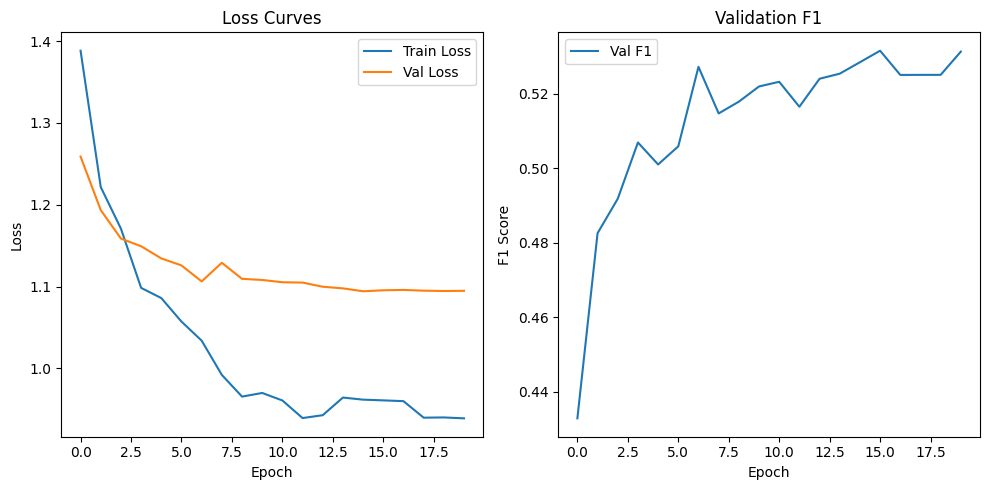

Best validation F1: 1.0943

Evaluating on test set...


/tmp/ipykernel_31/3936262603.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_PATH))


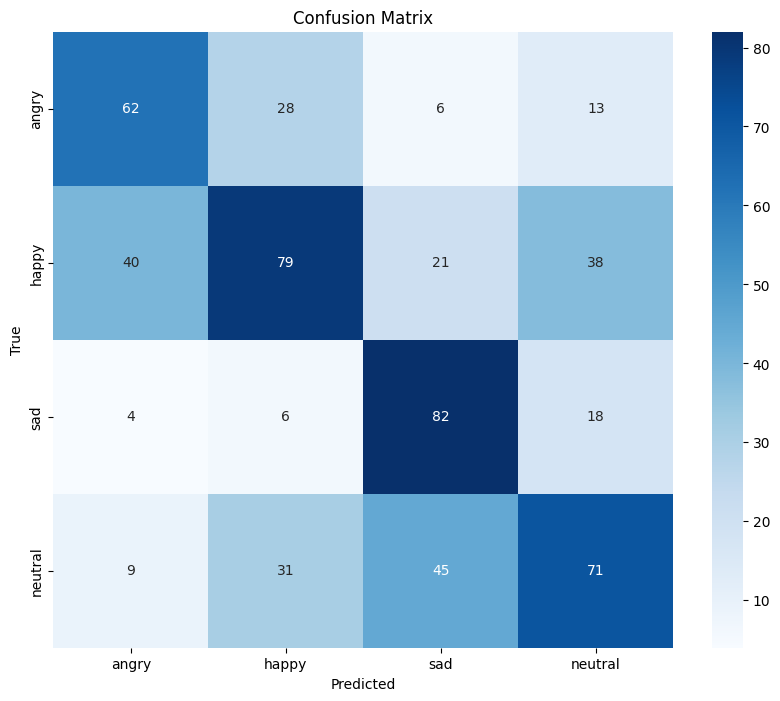

Test WA: 0.5316, UA: 0.5363, F1: 0.5260


In [129]:
# Initialize model
model = LSTMEmotionClassifier().to(DEVICE)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Train
print("Starting training...")
best_val_f1 = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, PATIENCE)
print(f"Best validation F1: {best_val_f1:.4f}")

# Evaluate on test set
print("\nEvaluating on test set...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
wa, ua, f1 = evaluate_model(model, test_loader, EMOTION_CLASSES)
print(f"Test WA: {wa:.4f}, UA: {ua:.4f}, F1: {f1:.4f}")

In [130]:
# Inference with audio playback
data = pd.read_csv(CSV_PATH)
sample_utt_ids = data['utt_id'].sample(5).tolist()
print("\nRunning inference with audio playback...")
results = infer(
    model, CSV_PATH, DATASET, sessions, utterance_ids=sample_utt_ids,
    max_len=MAX_LEN, n_mfcc=N_MFCC, mean=mean, std=std,
    emotion_classes=EMOTION_CLASSES, device=DEVICE
)

print("\nInference Results with Audio Playback:")
for res in results:
    print(f"\nUtterance: {res['utt_id']}")
    # Construct WAV path
    session = res['session']
    dialogue = res['utt_id'].rsplit('_', 1)[0]
    wav_path = os.path.join(DATASET, session, "sentences", "wav", dialogue, f"{res['utt_id']}.wav")
    try:
        y, sr = librosa.load(wav_path, sr=SR)
        display(Audio(data=y, rate=sr))
    except Exception as e:
        print(f"Audio playback failed for {res['utt_id']}: {e}")
        print(f"Expected WAV path: {wav_path}")
    print(f"Predicted Emotion: {res['emotion_pred']}")
    if 'emotion' in res:
        print(f"True Emotion: {res['emotion']}")


Running inference with audio playback...
Predicted for Ses01M_script03_2_M038: Emotion=angry
Predicted for Ses03F_script01_3_M045: Emotion=sad
Predicted for Ses03M_impro08b_F024: Emotion=neutral
Predicted for Ses05F_script03_2_M043: Emotion=angry
Predicted for Ses05M_script01_1b_M003: Emotion=sad

Inference Results with Audio Playback:

Utterance: Ses01M_script03_2_M038


Predicted Emotion: angry
True Emotion: angry

Utterance: Ses03F_script01_3_M045


Predicted Emotion: sad
True Emotion: happy

Utterance: Ses03M_impro08b_F024


Predicted Emotion: neutral
True Emotion: neutral

Utterance: Ses05F_script03_2_M043


Predicted Emotion: angry
True Emotion: angry

Utterance: Ses05M_script01_1b_M003


Predicted Emotion: sad
True Emotion: sad
